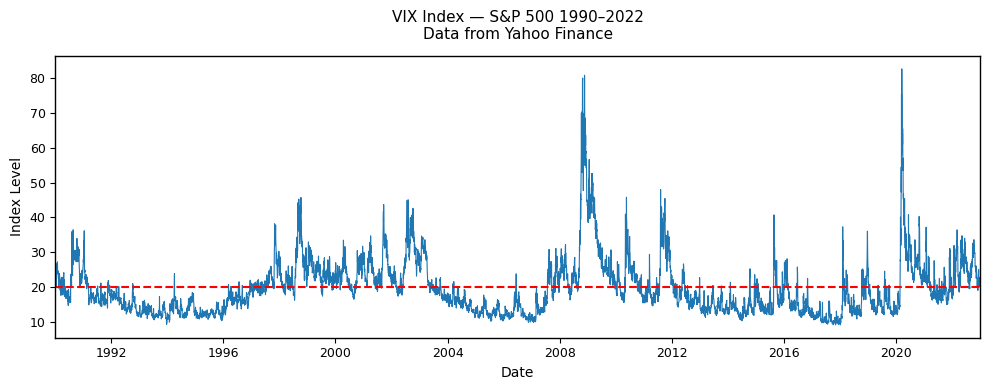

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

# Figure 1.3 — VIX volatility index
# This notebook downloads VIX data from Yahoo Finance
# and exports the volatility figure used in Chapter 1 of the thesis

# Output folder on the local machine
OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style settings
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# Data download and cleaning
df = yf.download(
    "^VIX",
    start="1990-01-01",
    end="2022-12-31",
    interval="1d",
    progress=False
)

# Handle possible multi-level columns returned by yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Remove missing observations
df = df.dropna()

# Figure construction
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    df.index,
    df["Close"],
    linewidth=0.8,
    color="#1f77b4"
)

# Long-run reference level used to identify elevated volatility
ax.axhline(y=20, color="red", linestyle="--", linewidth=1.5)

# Axis formatting and title
ax.set_title(
    "VIX Index — S&P 500 1990–2022\nData from Yahoo Finance",
    pad=12
)
ax.set_xlabel("Date")
ax.set_ylabel("Index Level")
ax.set_xlim(df.index.min(), df.index.max())

for spine in ax.spines.values():
    spine.set_linewidth(1)

ax.grid(False)

if ax.get_legend():
    ax.get_legend().remove()

# Export figure for the thesis
plt.tight_layout()
output_path = OUTPUT_DIR / "fig_1_3_vix_volatility.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()